# Feature Engineering II

**Applying time series data transformations in the native frequency.**

Author: Pete King

The data we get from FRED comes in different frequencies: quarterly, monthly, bi-weekly, and weekly.  Ideally we would like to apply our data transformations in the native frequency before incoroporating that data into a common Pandas DataFrame, which we will keep indexed by business days.  This section recreates the FRED data pull, but applies transformations before combining observations into a single DataFrame with a common index.

This avoids the situation where a zero-value appears as a difference or percent change after values had been forward-filled from a lower frequency to a higher frequency.


In [1]:
import numpy as np
import pandas as pd
from fredapi import Fred

import data_prep as dp

## I. Import FRED Data

This section is a copy from Tom's original notebook.

In [2]:
# Need an API key to access the FRED data
api_key = input("Enter your FRED API key: ")
fred = Fred(api_key=api_key)
print("Successfully connected to FRED API!")

Enter your FRED API key:  2e82bb1954b91cb0f75d7d8ca5397d30


Successfully connected to FRED API!


In [3]:
fred_data = dp.get_fred_data(fred)

## II. Compute stationary features

These computations are based on Tom's notebooks -- see those for rationale of first differencing for yields and percent change for macroeconomic and other data.

### Yield

Compute first difference (i.e., "delta" yield).

In [4]:
# Yield Columns
yield_cols = [
    'one_month_yield', 'three_month_yield', 'six_month_yield',
    'one_year_yield', 'two_year_yield', 'five_year_yield',
    'ten_year_yield', 'thirty_year_yield'
]

In [5]:
fred_transformed = {}
for series_name in yield_cols:
    fred_transformed[series_name + '_diff'] = fred_data[series_name].diff()

### Percentage Change

Compute percentage change.

In [6]:
# Columns to apply percentage change transformation
quarterly = [
    'nominal_GDP', 'real_GDP', 'debt_to_GDP', 'debt_interest',
    'consumer_price_index', 'core_PCI', 'personal_consumption_expenditure',
    'core_PCE', 'producer_price_index',
]
monthly = [
    'unemployment_rate',
    'teenager_unemployment_rate', 'adult_unemployment_rate',
    'male_unemployment_rate', 'female_unemployment_rate',
    'average_duration_of_unemployment'
]
weekly = [
    'initial_jobless_claims',
    'continued_jobless_claims'
]
pct_chg_cols = quarterly + monthly + weekly

In [7]:
for series_name in pct_chg_cols:
    fred_transformed[series_name + '_chg'] = fred_data[series_name].pct_change()

## III. Merge transformed data

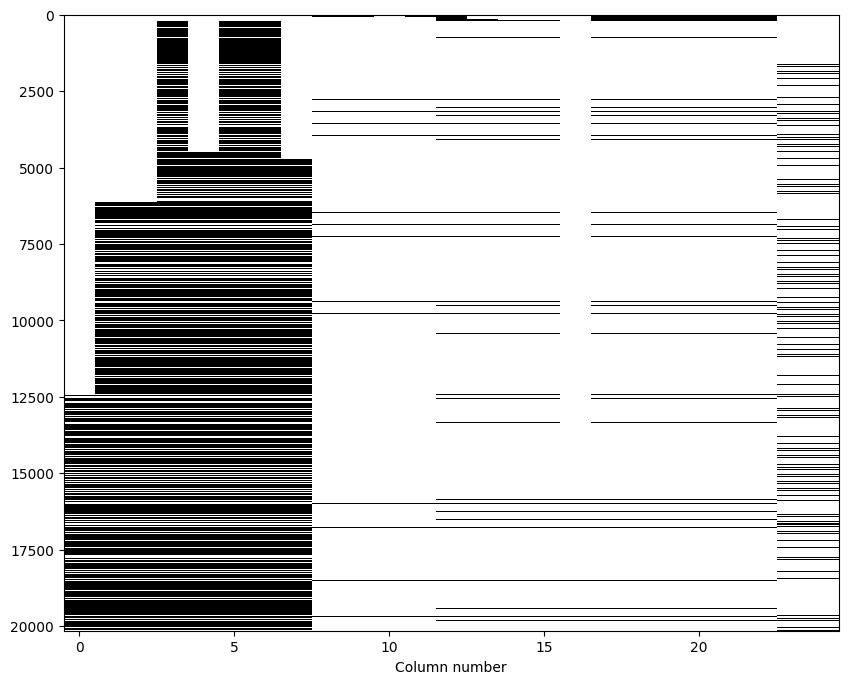

In [8]:
fred_df = pd.DataFrame(
    {name: series for name, series in fred_transformed.items()}
)
dp.view_nan(fred_df);

Because we joined time series of different frequencies on a common index, the resulting DataFrame is full of holes.  Here we choose to forward-fill data rather than perform some kind of interpolation.  The rationale is that these data come from reports that are released periodically.  No new information is available between reports.  Furthermore, we intend to merge this data later into a common DataFrame indexed by business day.

To ensure our final DataFrame will include a value for our mixed-frequency index variables at every business day, we create an empty DataFrame for business days during the period of interest, then do an outer join with the FRED data, and finally forward-fill missing values.  We then do a left join back to our empty business day index to keep only business days.

### Merge FRED data to with business day index and forward fill

#### Find date range

In [9]:
# Get starting date for the business day index
start_date = {}
for name, series in fred_transformed.items():
    start_date[name] = fred_transformed[name].index[0]
start_dates = sorted(
    [(name, date) for name, date in start_date.items()],
    key=lambda x:x[1]
)
start_dates[0]

('nominal_GDP_chg', Timestamp('1946-01-01 00:00:00'))

In [10]:
# Get final date for the business day index
final_date = {}
for name, series in fred_transformed.items():
    final_date[name] = fred_transformed[name].index[-1]
last_dates = sorted(
    [(name, date) for name, date in final_date.items()],
    key=lambda x:x[1]
)
last_dates[-1]

('thirty_year_yield_diff', Timestamp('2026-04-02 00:00:00'))

#### Create empty DataFrame with business day index

In [11]:
# Create the business day index as a Pandas Series object
bdays = pd.bdate_range(start=start_dates[0][1], end=last_dates[-1][1])
bdays

DatetimeIndex(['1946-01-01', '1946-01-02', '1946-01-03', '1946-01-04',
               '1946-01-07', '1946-01-08', '1946-01-09', '1946-01-10',
               '1946-01-11', '1946-01-14',
               ...
               '2026-03-20', '2026-03-23', '2026-03-24', '2026-03-25',
               '2026-03-26', '2026-03-27', '2026-03-30', '2026-03-31',
               '2026-04-01', '2026-04-02'],
              dtype='datetime64[us]', length=20938, freq='B')

In [12]:
# Create an empty DataFrame with a business day index for the desired time period
bday_df = pd.DataFrame({}, index=bdays)

#### Outer joing of FRED data with business days

In [13]:
# Outer join FRED data to the business day index
bday_fred_outer_df = pd.merge(
    left=bday_df,
    right=fred_df,
    how='outer',
    left_index=True,
    right_index=True
)
bday_fred_outer_df

,one_month_yield_diff,three_month_yield_diff,six_month_yield_diff,one_year_yield_diff,two_year_yield_diff,five_year_yield_diff,ten_year_yield_diff,thirty_year_yield_diff,nominal_GDP_chg,real_GDP_chg,...,core_PCE_chg,producer_price_index_chg,unemployment_rate_chg,teenager_unemployment_rate_chg,adult_unemployment_rate_chg,male_unemployment_rate_chg,female_unemployment_rate_chg,average_duration_of_unemployment_chg,initial_jobless_claims_chg,continued_jobless_claims_chg
1946-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1946-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1946-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1946-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1946-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.042654,NaN
2026-03-30,0.00,-0.02,-0.02,-0.06,-0.06,-0.09,-0.09,-0.07,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-03-31,0.00,-0.01,-0.01,-0.03,-0.03,-0.05,-0.05,-0.03,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-04-01,0.00,0.00,0.00,0.00,0.02,0.05,0.03,0.03,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


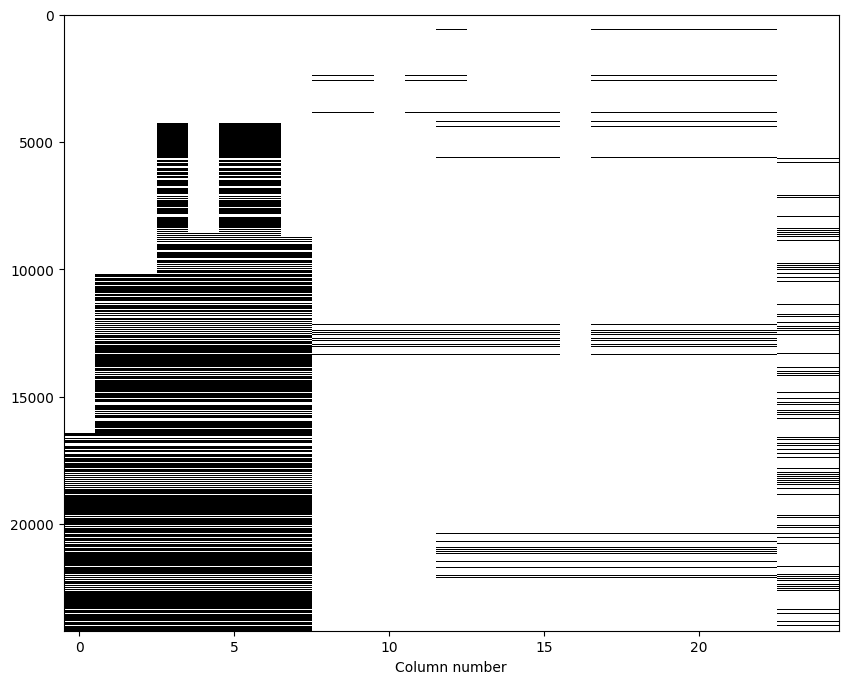

In [14]:
dp.view_nan(bday_fred_outer_df);

We can see that our original FRED data had many instances where a value was missing for a business day.  Next we forward fill the combined DataFrame so that every business date has a value, and then do an inner join to include only business days, which should be free of interspersed NaN values.

#### Forward fill, then left join to include only business days in the index

In [15]:
# Forward fill the "outer" DataFrame, then inner join to include only B-days
fred_final_df = pd.merge(
    left=bday_df,
    right=bday_fred_outer_df.ffill(),
    how='left',
    left_index=True,
    right_index=True
)
fred_final_df

,one_month_yield_diff,three_month_yield_diff,six_month_yield_diff,one_year_yield_diff,two_year_yield_diff,five_year_yield_diff,ten_year_yield_diff,thirty_year_yield_diff,nominal_GDP_chg,real_GDP_chg,...,core_PCE_chg,producer_price_index_chg,unemployment_rate_chg,teenager_unemployment_rate_chg,adult_unemployment_rate_chg,male_unemployment_rate_chg,female_unemployment_rate_chg,average_duration_of_unemployment_chg,initial_jobless_claims_chg,continued_jobless_claims_chg
1946-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1946-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1946-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1946-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1946-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-27,0.00,0.00,-0.02,-0.06,-0.08,-0.02,0.02,0.05,0.011076,0.001628,...,0.003635,0.00684,-0.022727,-0.080537,-0.05,-0.045455,-0.044444,-0.015564,0.029268,0.013767
2026-03-30,0.00,-0.02,-0.02,-0.06,-0.06,-0.09,-0.09,-0.07,0.011076,0.001628,...,0.003635,0.00684,-0.022727,-0.080537,-0.05,-0.045455,-0.044444,-0.015564,-0.042654,0.013767
2026-03-31,0.00,-0.01,-0.01,-0.03,-0.03,-0.05,-0.05,-0.03,0.011076,0.001628,...,0.003635,0.00684,-0.022727,-0.080537,-0.05,-0.045455,-0.044444,-0.015564,-0.042654,0.013767
2026-04-01,0.00,0.00,0.00,0.00,0.02,0.05,0.03,0.03,0.011076,0.001628,...,0.003635,0.00684,-0.022727,-0.080537,-0.05,-0.045455,-0.044444,-0.015564,-0.042654,0.013767


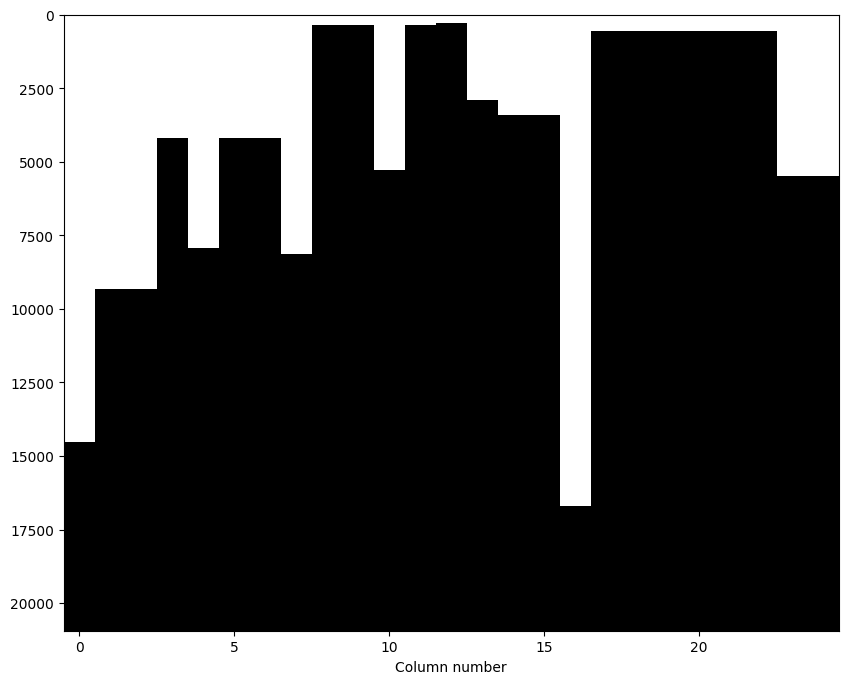

In [16]:
dp.view_nan(fred_final_df);

We now have a DataFrame indexed by business day and filled with transformed macroeconomic and other market index data.  Getting this right was a bit tricky and detail-oriented, but hopefully it will pay dividends when it comes to forecasting.

In [17]:
fred_final_df.to_csv('fred_transformed.csv', index_label='date')